<a href="https://colab.research.google.com/github/rafiaburdibaloch-ui/telco-churn-prediction/blob/main/churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print(df.shape)
print(df["Churn"].value_counts())
print(df["TotalCharges"].isna().sum(), "missing TotalCharges")

(7043, 21)
Churn
0    5174
1    1869
Name: count, dtype: int64
11 missing TotalCharges


imports

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay, roc_auc_score)

split first, then preprocess in a pipeline

In [ ]:
df = df.drop(columns=["customerID"])
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

compare six models

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                             scale_pos_weight=neg/pos, eval_metric="logloss", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=25),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, m in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", m)])
    s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    results[name] = s.mean()
    print(f"{name}: ROC-AUC {s.mean():.3f} (+/- {s.std():.3f})")

Logistic Regression: ROC-AUC 0.846 (+/- 0.012)
Random Forest: ROC-AUC 0.821 (+/- 0.011)
Extra Trees: ROC-AUC 0.788 (+/- 0.017)
Gradient Boosting: ROC-AUC 0.848 (+/- 0.012)
XGBoost: ROC-AUC 0.845 (+/- 0.011)
KNN: ROC-AUC 0.833 (+/- 0.009)


final test on the best model

Best model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

Test ROC-AUC: 0.843


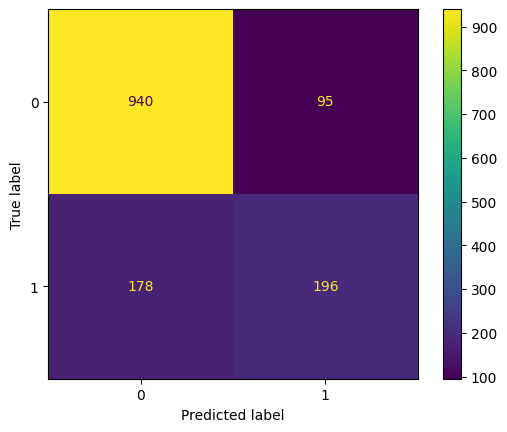

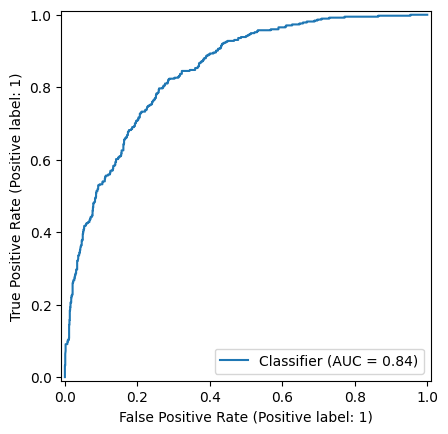

In [ ]:
best_name = max(results, key=results.get)
best_pipe = Pipeline([("prep", preprocess), ("model", models[best_name])]).fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

print("Best model:", best_name)
print(classification_report(y_test, y_pred))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred); plt.show()
RocCurveDisplay.from_predictions(y_test, y_prob); plt.show()

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

gb_pipe = Pipeline([("prep", preprocess), ("model", models[best_name])])
oof_prob = cross_val_predict(gb_pipe, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

rows = []
for t in np.arange(0.20, 0.61, 0.05):
    p = (oof_prob >= t).astype(int)
    rows.append((round(t, 2), precision_score(y_train, p), recall_score(y_train, p), f1_score(y_train, p)))

tbl = pd.DataFrame(rows, columns=["threshold", "precision", "recall", "f1"]).round(3)
print(tbl)

best_t = tbl.loc[tbl["f1"].idxmax(), "threshold"]
print("Best F1 threshold:", best_t)

   threshold  precision  recall     f1
0       0.20      0.485   0.851  0.617
1       0.25      0.512   0.801  0.625
2       0.30      0.545   0.757  0.633
3       0.35      0.578   0.704  0.635
4       0.40      0.610   0.645  0.627
5       0.45      0.638   0.591  0.614
6       0.50      0.660   0.534  0.590
7       0.55      0.684   0.457  0.548
8       0.60      0.705   0.383  0.496
Best F1 threshold: 0.35


              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1035
           1       0.56      0.71      0.63       374

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.78      1409



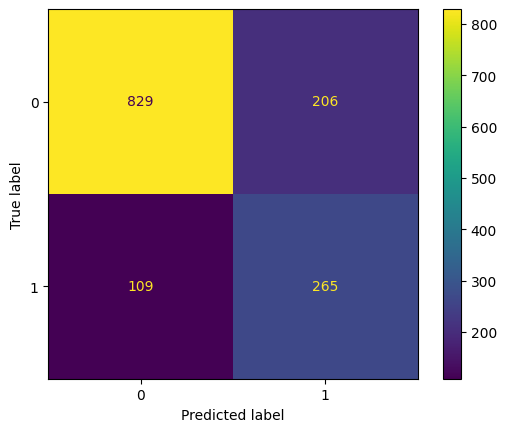

In [ ]:
best_pipe.fit(X_train, y_train)
y_prob = best_pipe.predict_proba(X_test)[:, 1]
y_pred_t = (y_prob >= best_t).astype(int)

print(classification_report(y_test, y_pred_t))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_t); plt.show()

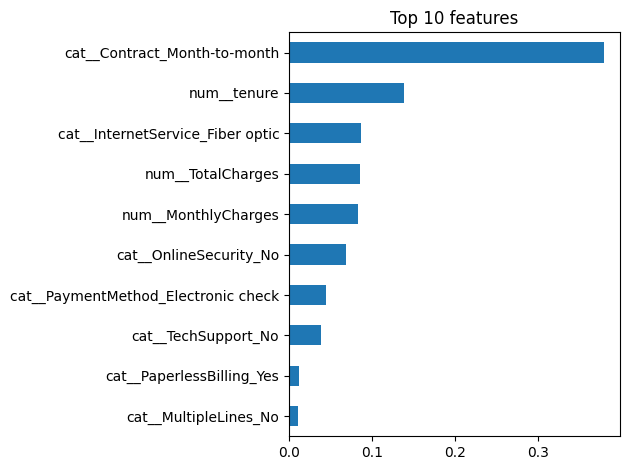

In [ ]:
feat_names = best_pipe.named_steps["prep"].get_feature_names_out()
imp = pd.Series(best_pipe.named_steps["model"].feature_importances_, index=feat_names)
imp.sort_values().tail(10).plot(kind="barh", title="Top 10 features")
plt.tight_layout(); plt.show()